# Convolutional Neural Networks — Hands-on with Keras

**Companion notebook to the hand-written class notes on:**
1. Convolution, Edge Detection & Other Primitive Detections
2. 3D Convolution & the Output-Shape Formula
3. Padding and Strides
4. Pooling

Each section below is written to be **self-contained** (it re-imports what it needs and redefines any helper function it uses), so you can safely split this file into separate notebooks for separate lecture sessions.

Wherever a Keras class/layer is used for the **first time**, a short note explains *what it does and how it's used* — this is meant to sit alongside the hand-written notes, not replace them.

---
## A one-minute primer on Keras

- **Keras** is the high-level deep-learning API bundled with TensorFlow as `tf.keras`. (Since Keras 3, the same code can also run on JAX/PyTorch backends — the API you write doesn't change.)
- A network is built out of **layers** (`keras.layers.*`) stacked into a **model**:
  - `keras.Sequential([...])` — a simple linear stack of layers. This is all we need for the demos in this notebook.
  - The **Functional API** (`keras.Model(inputs, outputs)`) is used later in the course for branching architectures (skip connections, multiple inputs/outputs, etc.).
- A model doesn't need to be *trained* to be *used*. Every layer holds weights (`layer.get_weights()` / `layer.set_weights()`), and calling `model.predict(x)` (or simply `model(x)`) runs data through it. In this notebook we deliberately **set the weights ourselves** (instead of training with `model.fit`) so we can see exactly what one specific convolution/pooling operation does to an image.

Run the setup cell below once, at the top.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("Keras version     :", keras.__version__)

np.random.seed(0)
plt.rcParams["figure.figsize"] = (10, 4)


TensorFlow version: 2.20.0
Keras version     : 3.13.2


---
# 1. Convolution, Edge Detection & Other Primitive Detections

### What is convolution doing?
A convolution slides a small matrix — the **kernel** (or **filter**) — over the image. At every position it takes an element-wise product between the kernel and the image patch underneath it, and sums the result into a single number. Repeating this at every position produces a new image, the **feature map**.

Different kernels pick out different *primitive* features — edges, blobs, blur, sharpen, etc. This is exactly what happens (with kernels **learned** automatically, not hand-picked) inside every `Conv2D` layer of a CNN. Below we hand-craft a few classic kernels — **Sobel** (edges), **Laplacian** (edges/detail), **box blur**, **sharpen**, **emboss** — and use a Keras `Conv2D` layer to apply them, purely to visualise what a convolution does.

### Keras layer used here: `keras.layers.Conv2D`

```python
keras.layers.Conv2D(
    filters,          # how many different kernels / output channels to learn
    kernel_size,      # e.g. (3, 3)
    strides=(1, 1),
    padding="valid",  # or "same" -- covered in Section 3
    activation=None,
    use_bias=True,
    input_shape=(H, W, C)   # only needed for the first layer of a Sequential model
)
```

- Normally the numbers inside the kernel are **learned** via backpropagation (`model.fit(...)`).
- Here we instead **inject our own kernel** with `layer.set_weights([kernel])`, so the convolution is fixed and we can see precisely what it computes.
- The weight shape Keras expects for `Conv2D` is `(kernel_height, kernel_width, in_channels, out_channels)`.

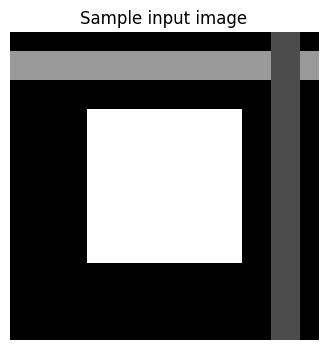

In [3]:
def create_sample_image(size=32):
    """A small synthetic grayscale image with clear horizontal, vertical and
    diagonal structure, so that edge-detecting kernels have something to find."""
    img = np.zeros((size, size), dtype="float32")
    img[8:24, 8:24] = 1.0     # solid square -> edges on all 4 sides
    img[2:5, :]     = 0.6     # thin horizontal stripe near the top
    img[:, 27:30]   = 0.3     # thin vertical stripe near the right
    return img

sample_image = create_sample_image()

plt.imshow(sample_image, cmap="gray")
plt.title("Sample input image")
plt.axis("off")
plt.show()


In [4]:
# A small library of classic 3x3 kernels
kernels = {
    "Vertical edge (Sobel-x)": np.array([[-1, 0, 1],
                                          [-2, 0, 2],
                                          [-1, 0, 1]], dtype="float32"),

    "Horizontal edge (Sobel-y)": np.array([[-1, -2, -1],
                                            [ 0,  0,  0],
                                            [ 1,  2,  1]], dtype="float32"),

    "Edges/detail (Laplacian)": np.array([[0,  1, 0],
                                           [1, -4, 1],
                                           [0,  1, 0]], dtype="float32"),

    "Box blur": np.ones((3, 3), dtype="float32") / 9.0,

    "Sharpen": np.array([[ 0, -1,  0],
                          [-1,  5, -1],
                          [ 0, -1,  0]], dtype="float32"),

    "Emboss": np.array([[-2, -1, 0],
                         [-1,  1, 1],
                         [ 0,  1, 2]], dtype="float32"),
}


In [5]:
def apply_kernel(image, kernel, padding="same"):
    """Runs `image` through a single-filter Conv2D layer whose weights are
    fixed to `kernel`, and returns the resulting 2D feature map."""
    img_batch = image.reshape(1, image.shape[0], image.shape[1], 1).astype("float32")
    kh, kw = kernel.shape

    conv_layer = keras.Sequential([
        layers.Conv2D(
            filters=1,
            kernel_size=(kh, kw),
            padding=padding,
            use_bias=False,
            input_shape=(image.shape[0], image.shape[1], 1),
        )
    ])

    # Conv2D kernel weight shape: (kernel_h, kernel_w, in_channels, out_channels)
    keras_kernel = kernel.reshape(kh, kw, 1, 1)
    conv_layer.set_weights([keras_kernel])

    feature_map = conv_layer.predict(img_batch, verbose=0)
    return feature_map[0, :, :, 0]


C:\Users\gauta\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


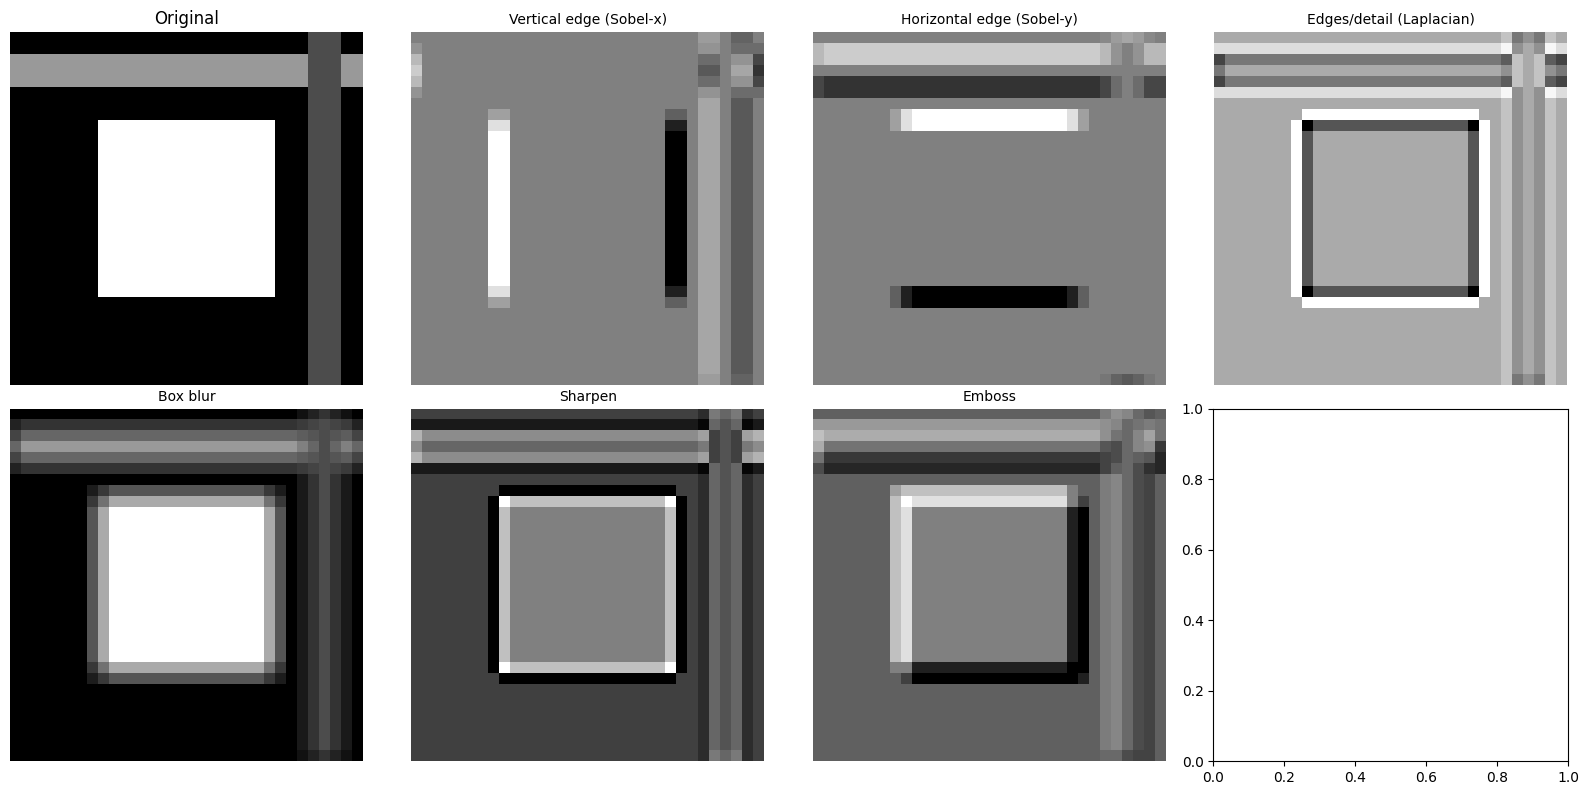

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

axes[0].imshow(sample_image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for ax, (name, kernel) in zip(axes[1:], kernels.items()):
    output = apply_kernel(sample_image, kernel, padding="same")
    ax.imshow(output, cmap="gray")
    ax.set_title(name, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


**What to notice**
- The *vertical* Sobel kernel lights up wherever intensity changes **left-to-right** (the vertical edges of the square and the vertical stripe).
- The *horizontal* Sobel kernel lights up wherever intensity changes **top-to-bottom**.
- The Laplacian responds to edges in *every* direction at once (it's a 2nd-derivative operator), but is noisier.
- Box blur / sharpen / emboss are examples of the many other "primitive" operations a single convolution can perform. A real CNN's first layer learns a mixture of dozens of such filters automatically, instead of us choosing them by hand.

---
# 2. 3D Convolution & the Output-Shape Formula

### Why 3D convolution?
`Conv2D` slides a 2D kernel over a 2D image (height x width). **`Conv3D`** slides a 3D kernel over a 3D volume — e.g. a short video clip (frames x height x width) or a medical scan (depth-slices x height x width). The extra axis is treated exactly like the spatial axes: the kernel also strides *along it*.

Keras input/kernel shapes for `Conv3D`:
- Input : `(batch, depth, height, width, channels)`
- Kernel: `(kernel_depth, kernel_height, kernel_width, in_channels, out_channels)`

### Keras layer used here: `keras.layers.Conv3D`

```python
keras.layers.Conv3D(
    filters,
    kernel_size,        # e.g. (3, 3, 3)
    strides=(1, 1, 1),
    padding="valid",     # or "same"
    activation=None,
    input_shape=(D, H, W, C)
)
```

### The output-shape formula
For **one spatial dimension** (this rule applies independently to depth, height and width — it's the exact rule `Conv1D`/`Conv2D`/`Conv3D` all use internally, one axis at a time):

$$ \text{output} = \left\lfloor \frac{\text{input} - \text{kernel} + 2P}{\text{stride}} \right\rfloor + 1 $$

Keras never asks you for `P` directly — instead you choose a `padding` mode:
- `padding="valid"` → no padding (`P = 0`): `output = floor((input - kernel) / stride) + 1`
- `padding="same"`  → Keras adds just enough padding that `output = ceil(input / stride)`

Let's turn that into code and check it against what Keras actually produces.

In [7]:
# (safe to re-run if you're using this section on its own)
import numpy as np
import math
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [8]:
def conv_output_shape(input_size, kernel_size, stride=1, padding="valid"):
    """Output size along ONE spatial dimension -- matches Keras's own rule
    for Conv1D / Conv2D / Conv3D (apply once per axis)."""
    if padding == "valid":
        return math.floor((input_size - kernel_size) / stride) + 1
    elif padding == "same":
        return math.ceil(input_size / stride)
    else:
        raise ValueError("padding must be 'valid' or 'same'")


In [9]:
# A tiny synthetic "video": 10 frames of 28x28 grayscale
video = np.random.rand(1, 10, 28, 28, 1).astype("float32")

conv3d = layers.Conv3D(
    filters=4,
    kernel_size=(3, 3, 3),
    strides=(1, 2, 2),
    padding="valid",
    input_shape=(10, 28, 28, 1),
)
model_3d = keras.Sequential([conv3d])
output_3d = model_3d.predict(video, verbose=0)

print("Input  shape:", video.shape)
print("Output shape:", output_3d.shape)

d_out = conv_output_shape(10, 3, stride=1, padding="valid")
h_out = conv_output_shape(28, 3, stride=2, padding="valid")
w_out = conv_output_shape(28, 3, stride=2, padding="valid")
print("Formula predicts (depth, height, width):", d_out, h_out, w_out)


Input  shape: (1, 10, 28, 28, 1)
Output shape: (1, 8, 13, 13, 4)
Formula predicts (depth, height, width): 8 13 13


In [10]:
# Cross-check the formula against Keras for several Conv2D configurations
print(f"{'kernel':>6} | {'stride':>6} | {'padding':>8} | {'formula':>8} | {'keras actual':>12}")
print("-" * 55)

input_size = 32
for kernel_size in [3, 5]:
    for stride in [1, 2]:
        for padding in ["valid", "same"]:
            layer = layers.Conv2D(
                filters=1, kernel_size=kernel_size, strides=stride,
                padding=padding, input_shape=(input_size, input_size, 1)
            )
            dummy = np.zeros((1, input_size, input_size, 1), dtype="float32")
            actual = layer(dummy).shape[1]   # height dimension of the output
            formula = conv_output_shape(input_size, kernel_size, stride, padding)
            print(f"{kernel_size:>6} | {stride:>6} | {padding:>8} | {formula:>8} | {actual:>12}")


kernel | stride |  padding |  formula | keras actual
-------------------------------------------------------
     3 |      1 |    valid |       30 |           30
     3 |      1 |     same |       32 |           32
     3 |      2 |    valid |       15 |           15
     3 |      2 |     same |       16 |           16
     5 |      1 |    valid |       28 |           28
     5 |      1 |     same |       32 |           32
     5 |      2 |    valid |       14 |           14
     5 |      2 |     same |       16 |           16


Notice the `formula` and `keras actual` columns always agree — that's the whole point of the shape formula: it lets you work out the size of every feature map in a network **on paper**, before ever running the code, which is exactly what you'll need for exam-style "compute the output shape" questions.

---
# 3. Padding and Strides

### Padding
Without padding, a convolution can only be centred on positions fully inside the image, so the feature map **shrinks** at every layer, and border pixels get looked at less often than centre pixels. **Padding** adds extra rows/columns (typically zeros) around the image before convolving.

Keras gives you two options directly inside `Conv2D` / `Conv3D` (no separate layer required):
- `padding="valid"` — no padding; output shrinks.
- `padding="same"` — Keras pads automatically so that, **when stride = 1**, output size = input size.

If you want to add padding *without* immediately convolving (e.g. to inspect it, or feed the padded image elsewhere), use the standalone layer:

```python
keras.layers.ZeroPadding2D(padding=(p_h, p_w))
```

### Strides
The **stride** is how many pixels the kernel jumps by at each step. `stride=1` moves one pixel at a time (dense, larger output); `stride=2` skips every other position (output roughly halved) — a common, cheap way to downsample instead of, or in addition to, pooling.

In [11]:
# (safe to re-run if you're using this section on its own)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_sample_image(size=32):
    img = np.zeros((size, size), dtype="float32")
    img[8:24, 8:24] = 1.0
    img[2:5, :] = 0.6
    img[:, 27:30] = 0.3
    return img

sample_image = create_sample_image()
img_batch = sample_image.reshape(1, 32, 32, 1)


In [12]:
for padding in ["valid", "same"]:
    layer = layers.Conv2D(filters=1, kernel_size=3, strides=1, padding=padding)
    out = layer(img_batch)
    print(f"padding={padding!r:8s} -> output shape {out.shape}")


padding='valid'  -> output shape (1, 30, 30, 1)
padding='same'   -> output shape (1, 32, 32, 1)


Original shape: (1, 32, 32, 1)
Padded shape  : (1, 40, 40, 1)


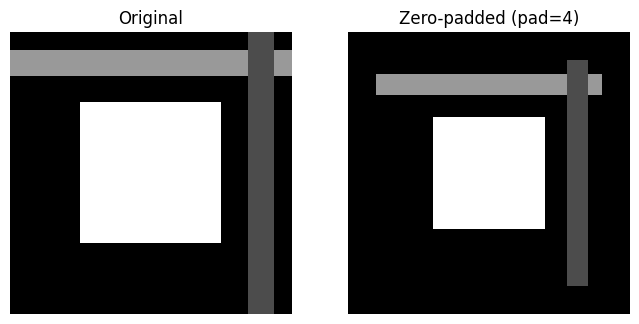

In [13]:
pad_layer = layers.ZeroPadding2D(padding=(4, 4))
padded_img = pad_layer(img_batch).numpy()

print("Original shape:", img_batch.shape)
print("Padded shape  :", padded_img.shape)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(padded_img[0, :, :, 0], cmap="gray")
axes[1].set_title("Zero-padded (pad=4)")
axes[1].axis("off")
plt.show()


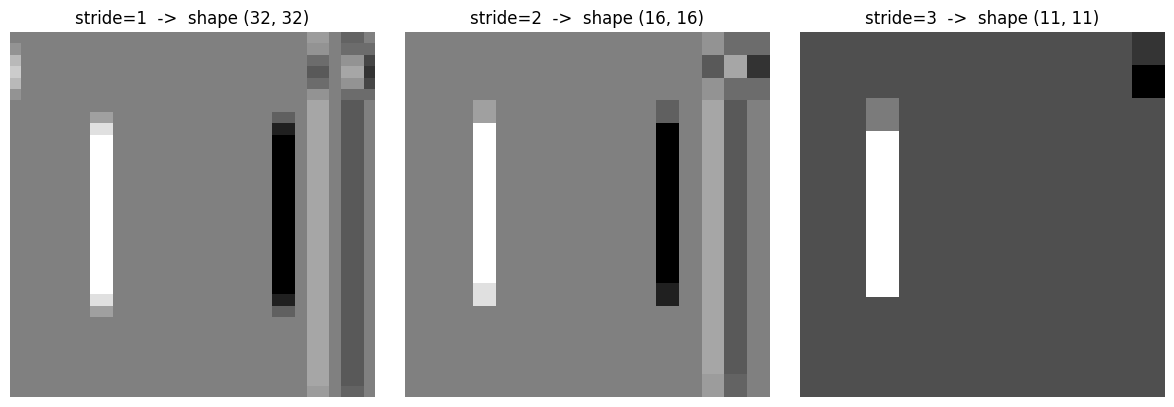

In [14]:
vertical_edge_kernel = np.array([[-1, 0, 1],
                                  [-2, 0, 2],
                                  [-1, 0, 1]], dtype="float32").reshape(3, 3, 1, 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, stride in zip(axes, [1, 2, 3]):
    layer = layers.Conv2D(filters=1, kernel_size=3, strides=stride,
                           padding="same", use_bias=False)
    layer.build((None, 32, 32, 1))
    layer.set_weights([vertical_edge_kernel])
    out = layer(img_batch).numpy()[0, :, :, 0]
    ax.imshow(out, cmap="gray")
    ax.set_title(f"stride={stride}  ->  shape {out.shape}")
    ax.axis("off")
plt.tight_layout()
plt.show()


Notice: with `padding="same"` and `stride=1` the output stays 32x32; as stride increases the feature map gets coarser (fewer pixels) but is computed faster and is cheaper to store — a real trade-off you'll make when designing a network.

---
# 4. Pooling

### Why pool?
Pooling further **downsamples** feature maps: it summarises each small neighbourhood into a single number. This (a) shrinks the amount of data flowing through the rest of the network, and (b) makes the representation a little more robust to small shifts/translations in the input.

Two common flavours, following the *exact same* sliding-window idea as convolution (with `pool_size` playing the role of `kernel_size` in the output-shape formula from Section 2):

- `keras.layers.MaxPooling2D(pool_size, strides=None, padding="valid")` — keeps the **maximum** value in each window. Good at preserving the strongest activation ("was this feature present anywhere in this region?").
- `keras.layers.AveragePooling2D(pool_size, strides=None, padding="valid")` — keeps the **average**. Smoother, keeps more background information.
- If `strides` isn't given, it defaults to `pool_size` (non-overlapping windows).

At the very end of many CNNs, right before the final `Dense` classification layer, you'll often see:
- `keras.layers.GlobalMaxPooling2D()` / `keras.layers.GlobalAveragePooling2D()` — collapse an *entire* `(H, W)` feature map, per channel, down to a **single number**, regardless of how big it is.

In [15]:
# (safe to re-run if you're using this section on its own)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_sample_image(size=32):
    img = np.zeros((size, size), dtype="float32")
    img[8:24, 8:24] = 1.0
    img[2:5, :] = 0.6
    img[:, 27:30] = 0.3
    return img

sample_image = create_sample_image()
img_batch = sample_image.reshape(1, 32, 32, 1)


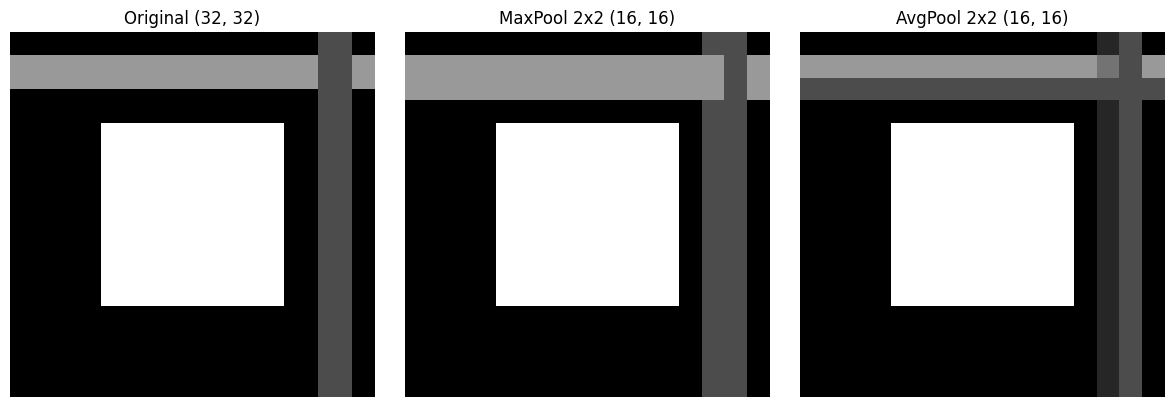

In [16]:
max_pool = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding="valid")
avg_pool = layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2), padding="valid")

max_out = max_pool(img_batch).numpy()[0, :, :, 0]
avg_out = avg_pool(img_batch).numpy()[0, :, :, 0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_image, cmap="gray")
axes[0].set_title(f"Original {sample_image.shape}")
axes[0].axis("off")
axes[1].imshow(max_out, cmap="gray")
axes[1].set_title(f"MaxPool 2x2 {max_out.shape}")
axes[1].axis("off")
axes[2].imshow(avg_out, cmap="gray")
axes[2].set_title(f"AvgPool 2x2 {avg_out.shape}")
axes[2].axis("off")
plt.tight_layout()
plt.show()


In [17]:
print(f"{'pool_size':>10} | {'strides':>8} | {'padding':>8} | output shape")
print("-" * 50)
for pool_size in [2, 3]:
    for strides in [None, 2]:
        for padding in ["valid", "same"]:
            layer = layers.MaxPooling2D(pool_size=pool_size, strides=strides, padding=padding)
            out = layer(img_batch)
            print(f"{pool_size:>10} | {str(strides):>8} | {padding:>8} | {out.shape}")


 pool_size |  strides |  padding | output shape
--------------------------------------------------
         2 |     None |    valid | (1, 16, 16, 1)
         2 |     None |     same | (1, 16, 16, 1)
         2 |        2 |    valid | (1, 16, 16, 1)
         2 |        2 |     same | (1, 16, 16, 1)
         3 |     None |    valid | (1, 10, 10, 1)
         3 |     None |     same | (1, 11, 11, 1)
         3 |        2 |    valid | (1, 15, 15, 1)
         3 |        2 |     same | (1, 16, 16, 1)


In [18]:
gmp = layers.GlobalMaxPooling2D()
gap = layers.GlobalAveragePooling2D()

print("Feature map shape           :", img_batch.shape)
print("After GlobalMaxPooling2D    :", gmp(img_batch).shape)
print("After GlobalAveragePooling2D:", gap(img_batch).shape)


Feature map shape           : (1, 32, 32, 1)
After GlobalMaxPooling2D    : (1, 1)
After GlobalAveragePooling2D: (1, 1)


---
## Quick recap

| Concept | Keras class / argument |
|---|---|
| 2D convolution | `layers.Conv2D` |
| 3D convolution | `layers.Conv3D` |
| Explicit / standalone padding | `layers.ZeroPadding2D` |
| Padding built into a conv layer | `padding="valid"` or `padding="same"` |
| Downsampling by skipping positions | `strides=` (inside `Conv2D`/`Conv3D`, or a pooling layer) |
| Max pooling | `layers.MaxPooling2D` |
| Average pooling | `layers.AveragePooling2D` |
| Collapse a whole feature map to 1 number/channel | `layers.GlobalMaxPooling2D` / `layers.GlobalAveragePooling2D` |

This notebook is meant to be read alongside the hand-written notes. Split it at the `# 1.` / `# 2.` / `# 3.` / `# 4.` headings into separate files for separate class sessions, if needed — each section re-imports and redefines everything it needs on its own.

# Gonzalez Test Image
This section loads a Gonzalez-style synthetic image containing strong horizontal and vertical lines and applies the same CNN operations (kernels, padding, stride, pooling) used earlier so the results can be compared with the original synthetic image.


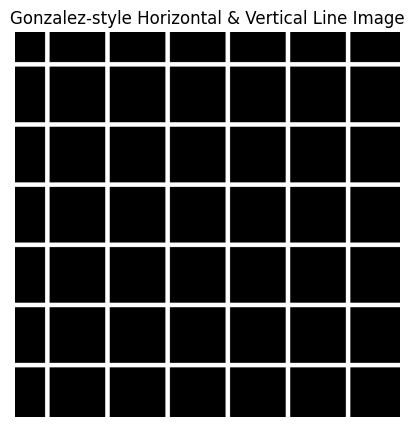

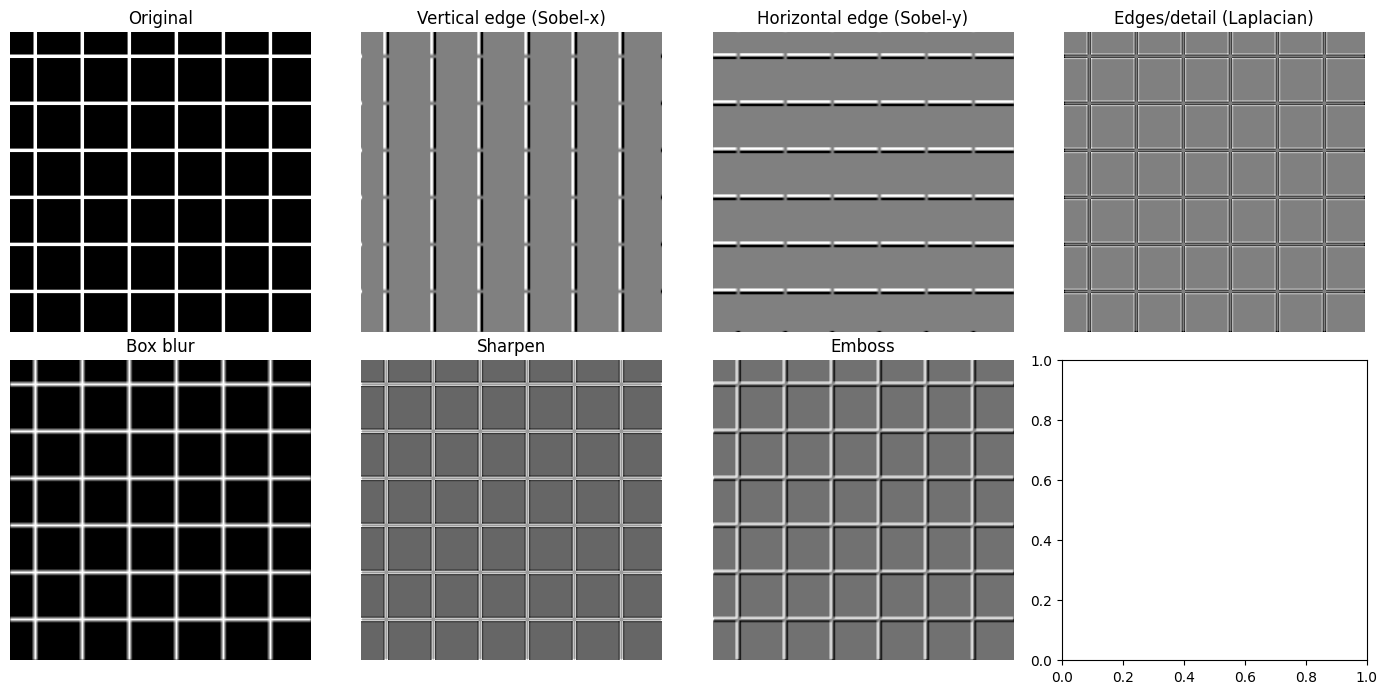

In [19]:

import numpy as np
import matplotlib.pyplot as plt

def create_gonzalez_image(size=256):
    img=np.zeros((size,size),dtype=np.float32)
    for i in range(20,size,40):
        img[i:i+3,:]=1.0
        img[:,i:i+3]=1.0
    return img

gonzalez_img=create_gonzalez_image()
plt.figure(figsize=(5,5))
plt.imshow(gonzalez_img,cmap='gray')
plt.title("Gonzalez-style Horizontal & Vertical Line Image")
plt.axis("off")
plt.show()

# Reuse previously defined kernels and apply_kernel()
try:
    fig,axs=plt.subplots(2,4,figsize=(14,7))
    axs=axs.ravel()
    axs[0].imshow(gonzalez_img,cmap='gray'); axs[0].set_title("Original"); axs[0].axis("off")
    names=list(kernels.keys())
    for ax,name in zip(axs[1:],names[:7]):
        out=apply_kernel(gonzalez_img,kernels[name])
        ax.imshow(out.squeeze(),cmap='gray')
        ax.set_title(name)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
except NameError:
    print("Run previous notebook cells first so 'kernels' and 'apply_kernel' are defined.")
